# Učitavanje podataka

In [1]:
import pandas as pd

df = pd.read_csv("../data/products.csv")

df.head()

,product ID,Product Title,Merchant ID,Category Label,_Product Code,Number_of_Views,Merchant Rating,Listing Date
0,1,apple iphone 8 plus 64gb silver,1,Mobile Phones,QA-2276-XC,860.0,2.5,5/10/2024
1,2,apple iphone 8 plus 64 gb spacegrau,2,Mobile Phones,KA-2501-QO,3772.0,4.8,12/31/2024
2,3,apple mq8n2b/a iphone 8 plus 64gb 5.5 12mp sim...,3,Mobile Phones,FP-8086-IE,3092.0,3.9,11/10/2024
3,4,apple iphone 8 plus 64gb space grey,4,Mobile Phones,YI-0086-US,466.0,3.4,5/2/2022
4,5,apple iphone 8 plus gold 5.5 64gb 4g unlocked ...,5,Mobile Phones,NZ-3586-WP,4426.0,1.6,4/12/2023


# Pregled podataka

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35311 entries, 0 to 35310
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   product ID       35311 non-null  int64  
 1   Product Title    35139 non-null  object 
 2   Merchant ID      35311 non-null  int64  
 3    Category Label  35267 non-null  object 
 4   _Product Code    35216 non-null  object 
 5   Number_of_Views  35297 non-null  float64
 6   Merchant Rating  35141 non-null  float64
 7    Listing Date    35252 non-null  object 
dtypes: float64(2), int64(2), object(4)
memory usage: 2.2+ MB


In [4]:
df.describe()

,product ID,Merchant ID,Number_of_Views,Merchant Rating
count,35311.000000,35311.000000,35297.000000,35141.000000
mean,26150.800176,120.501883,2501.469587,2.998261
std,13498.191220,117.045557,1438.217697,1.152664
min,1.000000,1.000000,0.000000,1.000000
25%,14958.500000,17.000000,1256.000000,2.000000
50%,27614.000000,75.000000,2509.000000,3.000000
75%,37508.500000,253.000000,3735.000000,4.000000
max,47358.000000,371.000000,5000.000000,5.000000


# Nedostajuće vrednosti

In [5]:
df.isnull().sum()

product ID           0
Product Title      172
Merchant ID          0
 Category Label     44
_Product Code       95
Number_of_Views     14
Merchant Rating    170
 Listing Date       59
dtype: int64

# Distribucija kategorija

In [9]:
df.columns = df.columns.str.strip()

In [10]:
df["Category Label"].value_counts().head(20)

Category Label
Fridge Freezers     5495
Washing Machines    4036
Mobile Phones       4020
CPUs                3771
TVs                 3564
Fridges             3457
Dishwashers         3418
Digital Cameras     2696
Microwaves          2338
Freezers            2210
fridge               123
CPU                   84
Mobile Phone          55
Name: count, dtype: int64

# Vizualizacija kategorija

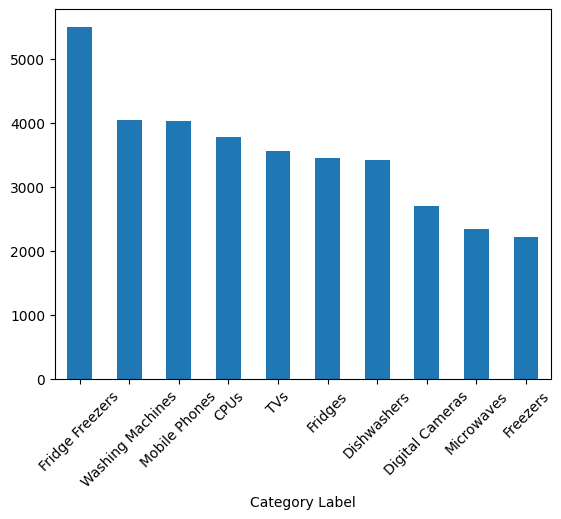

In [11]:
import matplotlib.pyplot as plt

df["Category Label"].value_counts().head(10).plot(kind="bar")

plt.xticks(rotation=45)
plt.show()

# Inženjering karakteristika

In [17]:
import re
import pandas as pd

In [18]:
def analyze_title(x):
    if pd.isna(x):
        return pd.Series([0, 0, 0])  # title_length, word_count, has_numbers
    x_str = str(x)
    title_length = len(x_str)
    word_count = len(x_str.split())
    has_numbers = int(bool(re.search(r'\d', x_str)))
    return pd.Series([title_length, word_count, has_numbers])

df[['title_length', 'word_count', 'has_numbers']] = df['Product Title'].apply(analyze_title)

# TF-IDF transformacija teksta

In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer

# zameni NaN praznim stringom
titles = df["Product Title"].fillna("")

tfidf = TfidfVectorizer(stop_words="english", max_features=5000)
X_text = tfidf.fit_transform(titles)

# Ciljna promenljiva

In [21]:
y = df["Category Label"]

# Podela podataka

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_text,
    y,
    test_size=0.2,
    random_state=42
)

# Treniranje modela

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack, csr_matrix
from sklearn.linear_model import LogisticRegression

df_clean = df[df["Category Label"].notna()]
y = df_clean["Category Label"]
titles = df_clean["Product Title"].fillna("")
tfidf = TfidfVectorizer(stop_words="english", max_features=5000)
X_text = tfidf.fit_transform(titles)
X_num = df_clean[["title_length", "word_count", "has_numbers"]].fillna(0)
X = hstack([X_text, csr_matrix(X_num)])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

c:\Users\Sandra Vorkapic\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


# Evaluacija modela

In [28]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

y_pred = model.predict(X_test)

accuracy_score(y_test, y_pred)

0.9360646441735185

In [29]:
print(classification_report(y_test, y_pred))

                  precision    recall  f1-score   support

             CPU       0.00      0.00      0.00         9
            CPUs       0.99      0.99      0.99       748
 Digital Cameras       1.00      0.97      0.99       536
     Dishwashers       0.89      0.95      0.92       674
        Freezers       0.99      0.87      0.93       452
 Fridge Freezers       0.94      0.90      0.92      1079
         Fridges       0.83      0.89      0.86       719
      Microwaves       0.99      0.93      0.96       455
    Mobile Phone       0.00      0.00      0.00        16
   Mobile Phones       0.91      0.99      0.95       800
             TVs       0.96      0.98      0.97       728
Washing Machines       0.93      0.95      0.94       813
          fridge       0.00      0.00      0.00        25

        accuracy                           0.94      7054
       macro avg       0.73      0.72      0.72      7054
    weighted avg       0.93      0.94      0.93      7054



c:\Users\Sandra Vorkapic\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Sandra Vorkapic\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Sandra Vorkapic\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control 

In [30]:
confusion_matrix(y_test, y_pred)

array([[  0,   9,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0, 737,   0,   0,   0,   0,   2,   0,   0,   6,   3,   0,   0],
       [  0,   0, 522,   0,   0,   2,   0,   0,   0,  11,   1,   0,   0],
       [  0,   0,   0, 640,   0,   6,   5,   0,   0,   8,   1,  14,   0],
       [  0,   0,   0,   5, 393,   9,  28,   0,   0,   4,   2,  11,   0],
       [  0,   0,   0,  26,   0, 974,  53,   0,   0,   9,   5,  12,   0],
       [  0,   0,   0,  17,   2,  36, 643,   0,   0,  10,   2,   9,   0],
       [  0,   0,   0,   6,   0,   1,  12, 422,   0,   3,   4,   7,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,  16,   0,   0,   0],
       [  0,   0,   1,   0,   0,   1,   0,   1,   0, 792,   4,   1,   0],
       [  0,   0,   0,   0,   0,   0,   0,   2,   0,   9, 711,   6,   0],
       [  0,   0,   0,  22,   0,   0,   9,   0,   0,   6,   7, 769,   0],
       [  0,   0,   0,   0,   0,   2,  22,   0,   0,   0,   0,   1,   0]])

# Čuvanje modela

In [31]:
import joblib

joblib.dump(model, "../models/model.pkl")

joblib.dump(tfidf, "../models/vectorizer.pkl")

['../models/vectorizer.pkl']